In [3]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


In [4]:
CHECKPOINT_PATH = "sam_vit_b.pth"   # path to your SAM checkpoint
MODEL_TYPE = "vit_b"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device)

predictor = SamPredictor(sam)


(np.float64(-0.5), np.float64(1724.5), np.float64(1724.5), np.float64(-0.5))

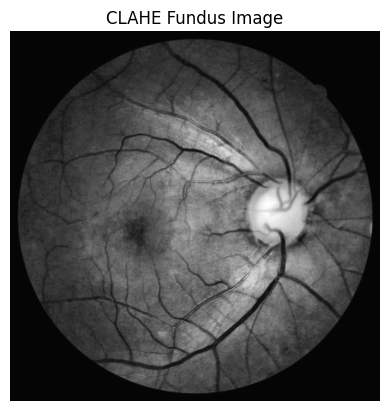

In [8]:
image_path = "superior (1).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(5183.5), np.float64(3455.5), np.float64(-0.5))

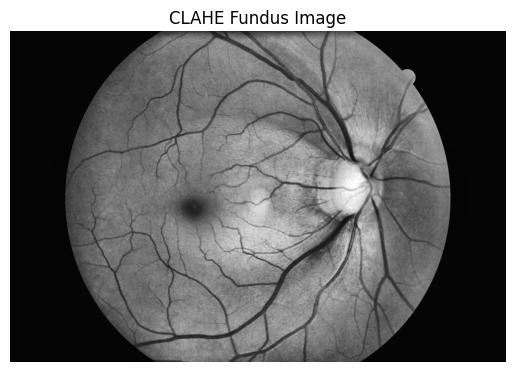

In [9]:
image_path = "superior (2).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(2735.5), np.float64(1823.5), np.float64(-0.5))

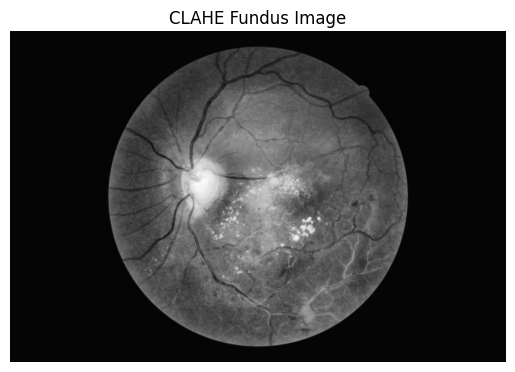

In [10]:
image_path = "superior (3).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

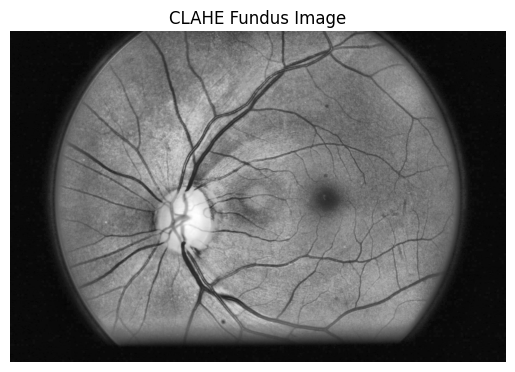

In [11]:
image_path = "superior (4).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(4927.5), np.float64(3263.5), np.float64(-0.5))

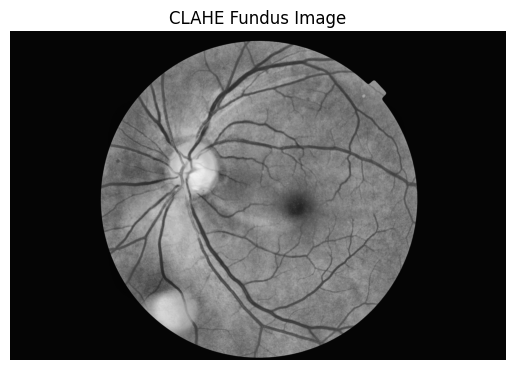

In [12]:
image_path = "inferior (1).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(4927.5), np.float64(3263.5), np.float64(-0.5))

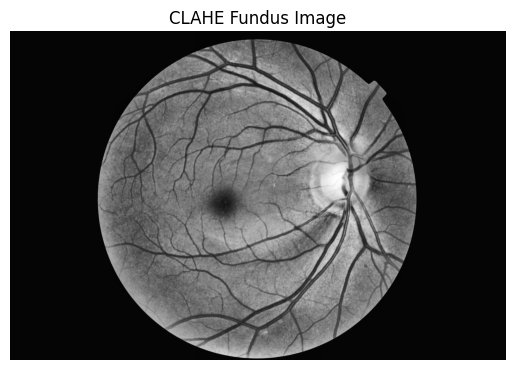

In [13]:
image_path = "inferior (2).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(3887.5), np.float64(2591.5), np.float64(-0.5))

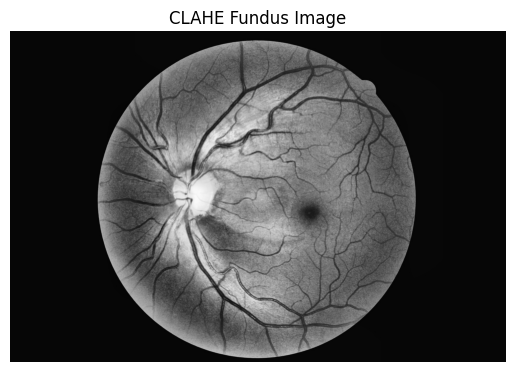

In [14]:
image_path = "inferior (3).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

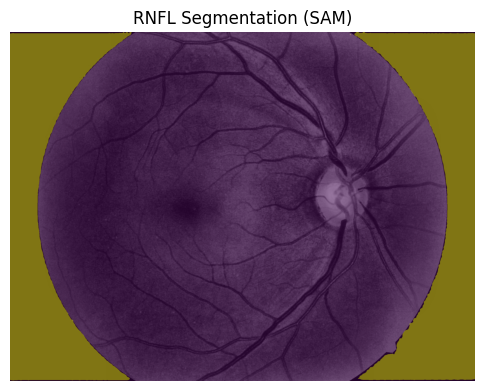

In [23]:
predictor.set_image(image_rgb)
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

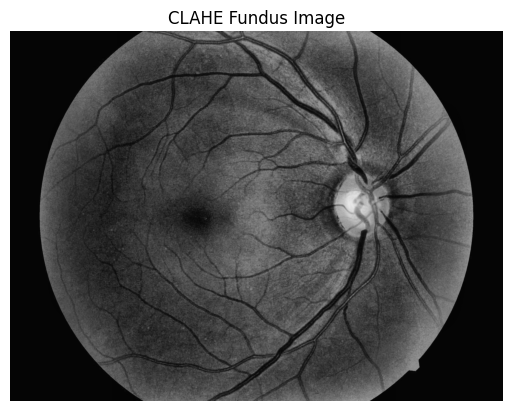

In [15]:
image_path = "inferior (4).jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


In [16]:
predictor.set_image(image_rgb)


In [17]:
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground


In [18]:
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])


In [19]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


(np.float64(-0.5), np.float64(2559.5), np.float64(1919.5), np.float64(-0.5))

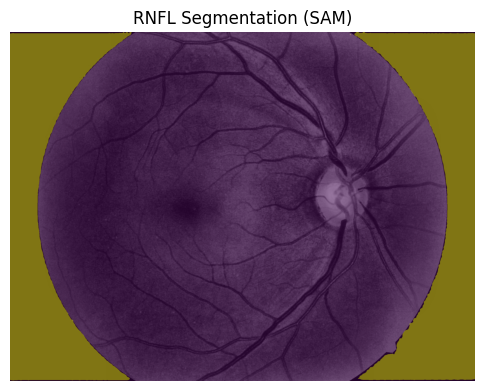

In [20]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


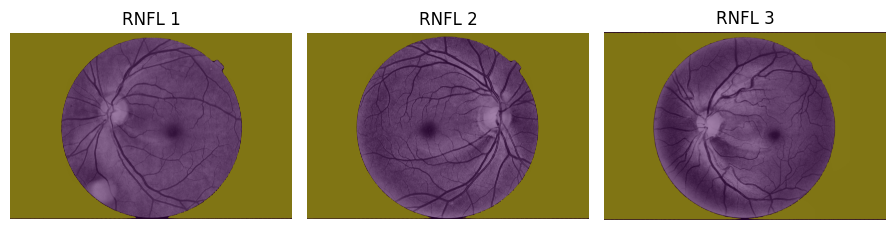

In [24]:
image_paths = [
    "inferior (1).jpg",
    "inferior (2).jpg",
    "inferior (3).jpg",
    "inferior (4).jpg",
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


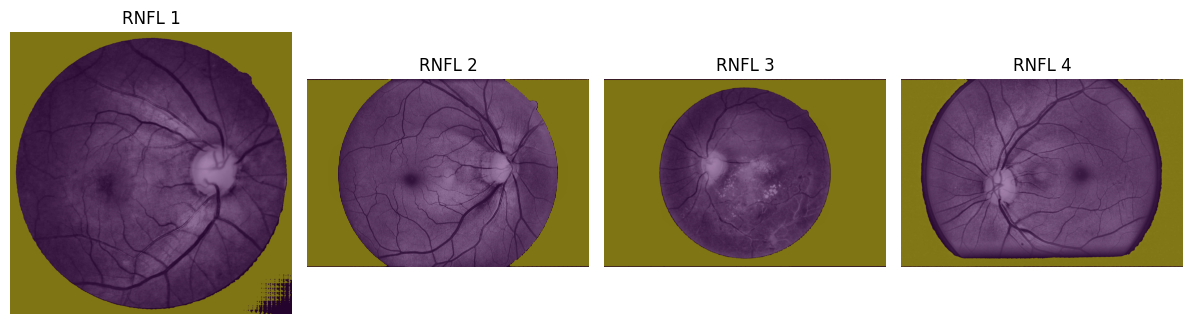

In [26]:
image_paths = [
    "superior (1).jpg",
    "superior (2).jpg",
    "superior (3).jpg",
    "superior (4).jpg",
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


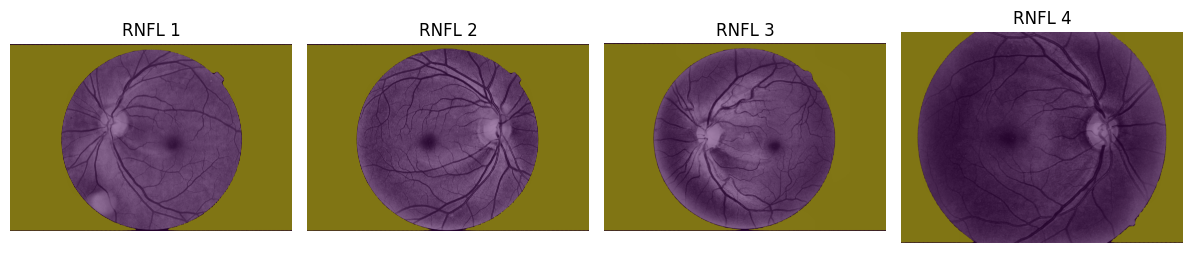

In [35]:
image_paths = [
    "inferior (1).jpg",
    "inferior (2).jpg",
    "inferior (3).jpg",
    "inferior (4).jpg",
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


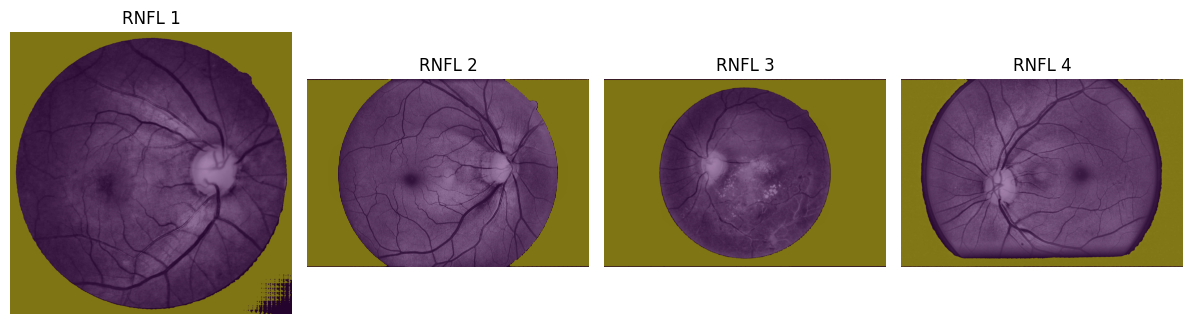

In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- CREATE OUTPUT FOLDER --------
output_dir = "sam_outputs"
os.makedirs(output_dir, exist_ok=True)

image_paths = [
    "superior (1).jpg",
    "superior (2).jpg",
    "superior (3).jpg",
    "superior (4).jpg",
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: SAVE EXACT OUTPUT --------
    plt.savefig(
        os.path.join(output_dir, f"output_{i+1}.png"),
        bbox_inches="tight",
        dpi=300
    )

plt.tight_layout()
plt.show()


In [56]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- CREATE OUTPUT FOLDER --------
output_dir = "sam_outputi"
os.makedirs(output_dir, exist_ok=True)

image_paths = [
    "inferior (1).jpg",
    "inferior (2).jpg",
    "inferior (3).jpg",
    "inferior (4).jpg",
]

for i, image_path in enumerate(image_paths):

    # -------- NEW FIGURE FOR EACH IMAGE --------
    plt.figure(figsize=(5,5))

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: SAVE EXACT OUTPUT --------
    plt.savefig(
        os.path.join(output_dir, f"output_{i+1}.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.close()   # IMPORTANT

plt.show()


In [57]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- CREATE OUTPUT FOLDER --------
output_dir = "sam_outputi"
os.makedirs(output_dir, exist_ok=True)

image_paths = [
    "inf1.jpg",
    "inf2.jpg",
    "inf3.jpg",
    "inf4.jpg",
]

for i, image_path in enumerate(image_paths):

    # -------- NEW FIGURE FOR EACH IMAGE --------
    plt.figure(figsize=(5,5))

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: SAVE EXACT OUTPUT --------
    plt.savefig(
        os.path.join(output_dir, f"output_{i+1}.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.close()   # IMPORTANT

plt.show()


In [58]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- CREATE OUTPUT FOLDER --------
output_dir = "sam_outputi"
os.makedirs(output_dir, exist_ok=True)

image_paths = [
    "inf5.jpg",
    "inf6.jpg",
    "inf7.jpg",
    "inf8.jpg",
]

for i, image_path in enumerate(image_paths):

    # -------- NEW FIGURE FOR EACH IMAGE --------
    plt.figure(figsize=(5,5))

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: SAVE EXACT OUTPUT --------
    plt.savefig(
        os.path.join(output_dir, f"output_{i+1}.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.close()   # IMPORTANT

plt.show()


In [59]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- OUTPUT FOLDER --------
output_dir = "sam_rnfl_defect"
os.makedirs(output_dir, exist_ok=True)

image_paths = [
    "inferior (1).jpg",
]

for i, image_path in enumerate(image_paths):

    plt.figure(figsize=(5,5))

    # -------- Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- RNFL DEFECT BOX (example – adjust once) --------
    # Box format: [x1, y1, x2, y2]
    # From optic disc → outward wedge direction
    rnfl_box = np.array([
        500, 250,   # near optic disc
        900, 550    # outward wedge region
    ])

    # -------- SAM prediction --------
    masks, scores, _ = predictor.predict(
        box=rnfl_box[None, :],
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- Visualization --------
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL Defect {i+1}")
    plt.axis("off")

    # -------- Save exact output --------
    plt.savefig(
        os.path.join(output_dir, f"rnfl_defect_{i+1}.png"),
        bbox_inches="tight",
        dpi=300
    )

    plt.close()

plt.show()


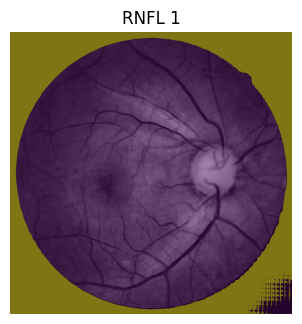

In [60]:
image_paths = [
    "superior (1).jpg",
    
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


In [3]:
import matplotlib.pyplot as plt


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [8]:
from segment_anything import sam_model_registry, SamPredictor


In [6]:
image_paths = [
    "inferior (1).jpg",
    
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


NameError: name 'predictor' is not defined

<Figure size 1500x600 with 0 Axes>